In [1]:
import netCDF4 as nc
import matplotlib.pyplot as plt
from matplotlib.colors import from_levels_and_colors
import numpy as np
from matplotlib import animation
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as cols
import matplotlib as mpl
from mpl_toolkits.basemap import Basemap
from matplotlib import ticker, cm
import seaborn as sns

In [2]:
data=nc.Dataset('/home/iHESPdata/B.E.13.B1850C5.ne120_t12.sehires38.003.sunway_02.pop.h.0495-12.nc')
lont = data.variables['TLONG'][:240,1100]
latt = data.variables['TLAT'][:240,1100]
lont[lont==-1]=np.nan
latt[latt==-1]=np.nan

In [3]:
ascno = np.load('/media/ub/Elements/iHESPdata/ASCalongallno.npy')
ascyes = np.load('/media/ub/Elements/iHESPdata/ASCalongallyes.npy')

In [4]:
ascyes.shape

(250, 428, 3600)

In [5]:
AA = ascyes[60,:240,1100]

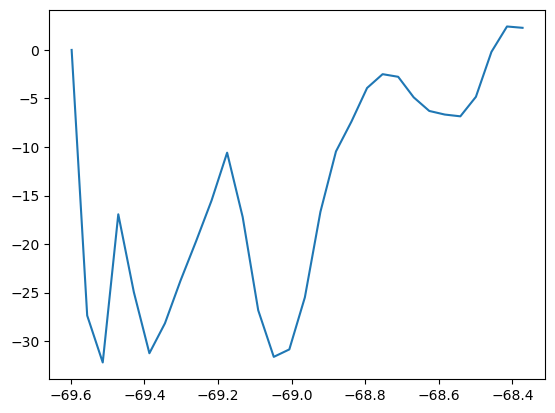

In [6]:
plt.plot(latt,AA)

In [7]:
all1 = np.zeros((250))
for ii in range(0,250):
    all1[ii] = np.nanmin(ascyes[ii,:240,1100])

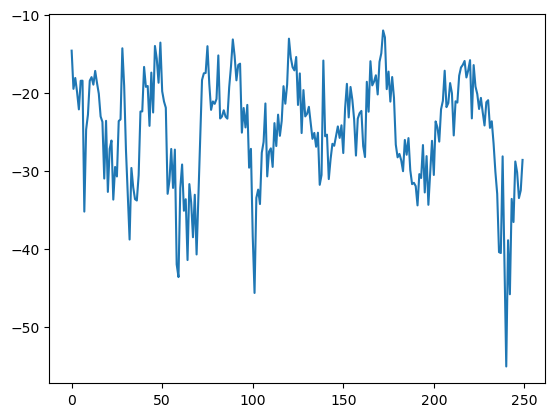

In [8]:
plt.plot(all1)

In [9]:
arr = all1
window_size = 5

i = 0
# Initialize an empty list to store moving averages
moving_averages = []

# Loop through the array t o
#consider every window of size 3
while i < len(arr) - window_size + 1:

    # Calculate the average of current window
    window_average = round(np.sum(arr[
      i:i+window_size]) / window_size, 2)
    
    # Store the average of current
    # window in moving average list
    moving_averages.append(window_average)
    
    # Shift window to right by one position
    i += 1

In [10]:
# Low-Pass (lp) anomalies:
anom = moving_averages

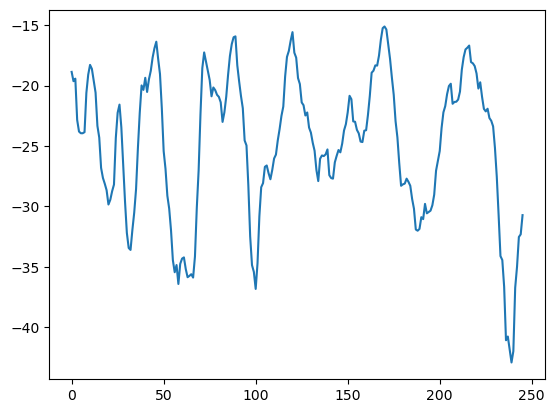

In [11]:
plt.plot(anom)

In [12]:
WSPno = np.load('/media/ub/Elements/iHESPplot/iceplot/smallMRP.npy')
WSPbigger = np.load('/media/ub/Elements/iHESPplot/iceplot/smallWSP.npy')

In [13]:
DSW1 = np.load('/media/ub/Elements/iHESPplot/iceplot/cross1000sigma1/weDSW1plusplusrun.npy')
DSW1time = np.load('/media/ub/Elements/iHESPplot/iceplot/cross1000sigma1/we2timeplusplusrun.npy')

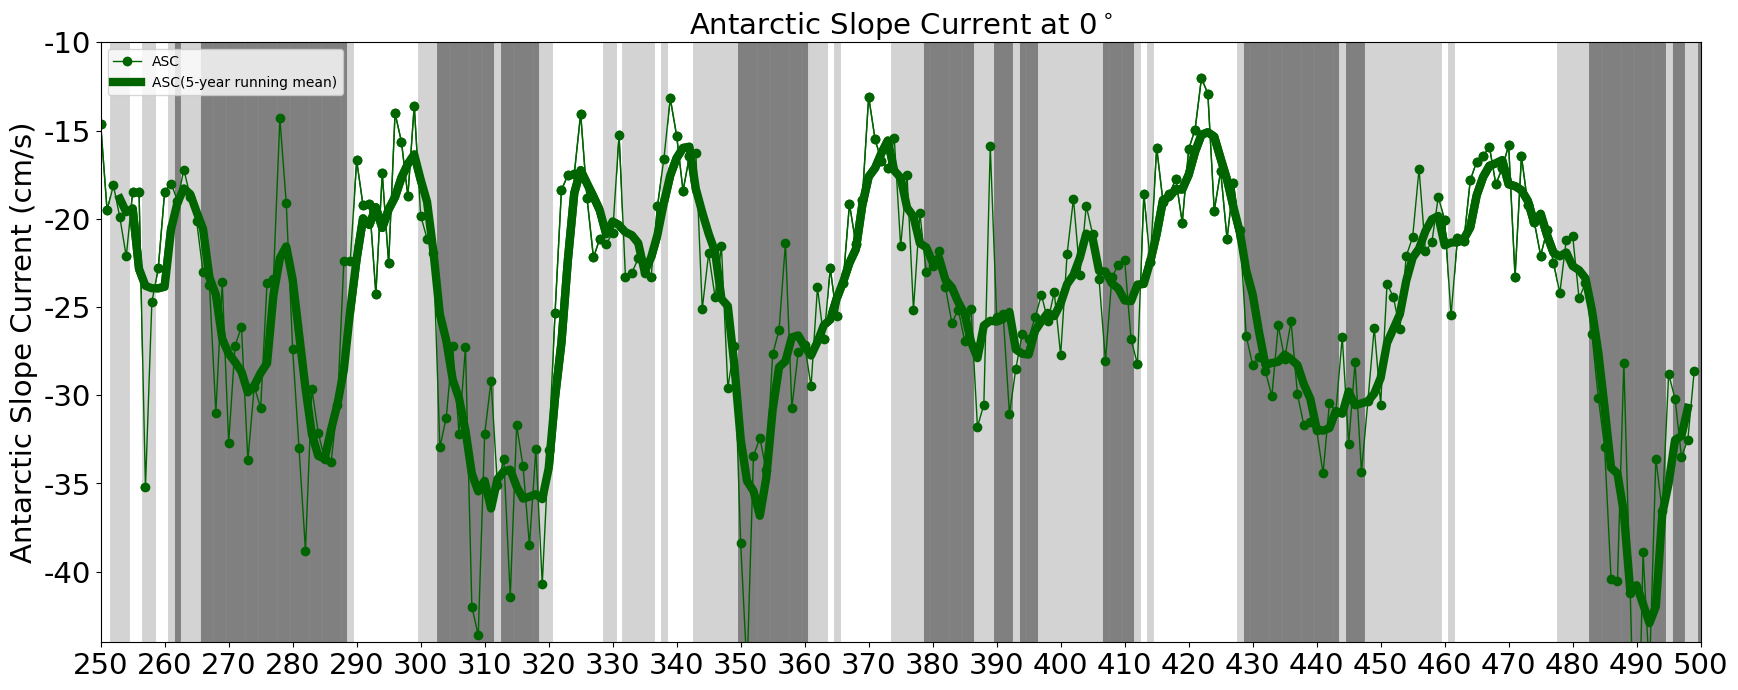

In [14]:
fig = plt.figure(figsize=(20,20), dpi=100)
my_font = { 'size':'21'}
################################################################
################################################################
t = np.arange(3,249,1)
ax1 = fig.add_axes([0.1, 0.9, 0.8, 0.3],
                   xticklabels=[])
ax1.plot(all1,color='darkgreen',marker='o',linewidth=1,label='ASC')

ax1.plot(t, anom,color='darkgreen',linewidth=6,label='ASC(5-year running mean)')
plt.legend(loc='upper left')#,fontsize='xx-large')
#plt.legend()
plt.vlines(WSPbigger, -45, -10, linestyles="solid", colors="grey" ,linewidth=5)
plt.vlines(WSPno, -45, -10, linestyles="solid", colors="lightgrey" ,linewidth=5)
ax1.plot(all1,color='darkgreen',marker='o',linewidth=1,label='ASC')

ax1.plot(t, anom,color='darkgreen',linewidth=6,label='ASC(5-year running mean)')
plt.axis("tight")
plt.yticks(np.arange(-45,-5,5), ['-45','-40','-35','-30','-25','-20','-15','-10'],**my_font)
plt.ylabel('Antarctic Slope Current (cm/s)',**my_font)
plt.title('Antarctic Slope Current at 0$^\circ$',**my_font)
plt.xticks(np.arange(0,260,10), ['250','260','270','280','290','300','310','320','330','340','350','360','370','380','390','400','410','420','430','440','450','460','470','480','490','500'],**my_font)
ax1.set(ylim=(-44, -10),xlim=(0, 250))




plt.savefig("ASCtime.png",bbox_inches='tight')

[(0.0, 8.0), (0.0, 250.0)]

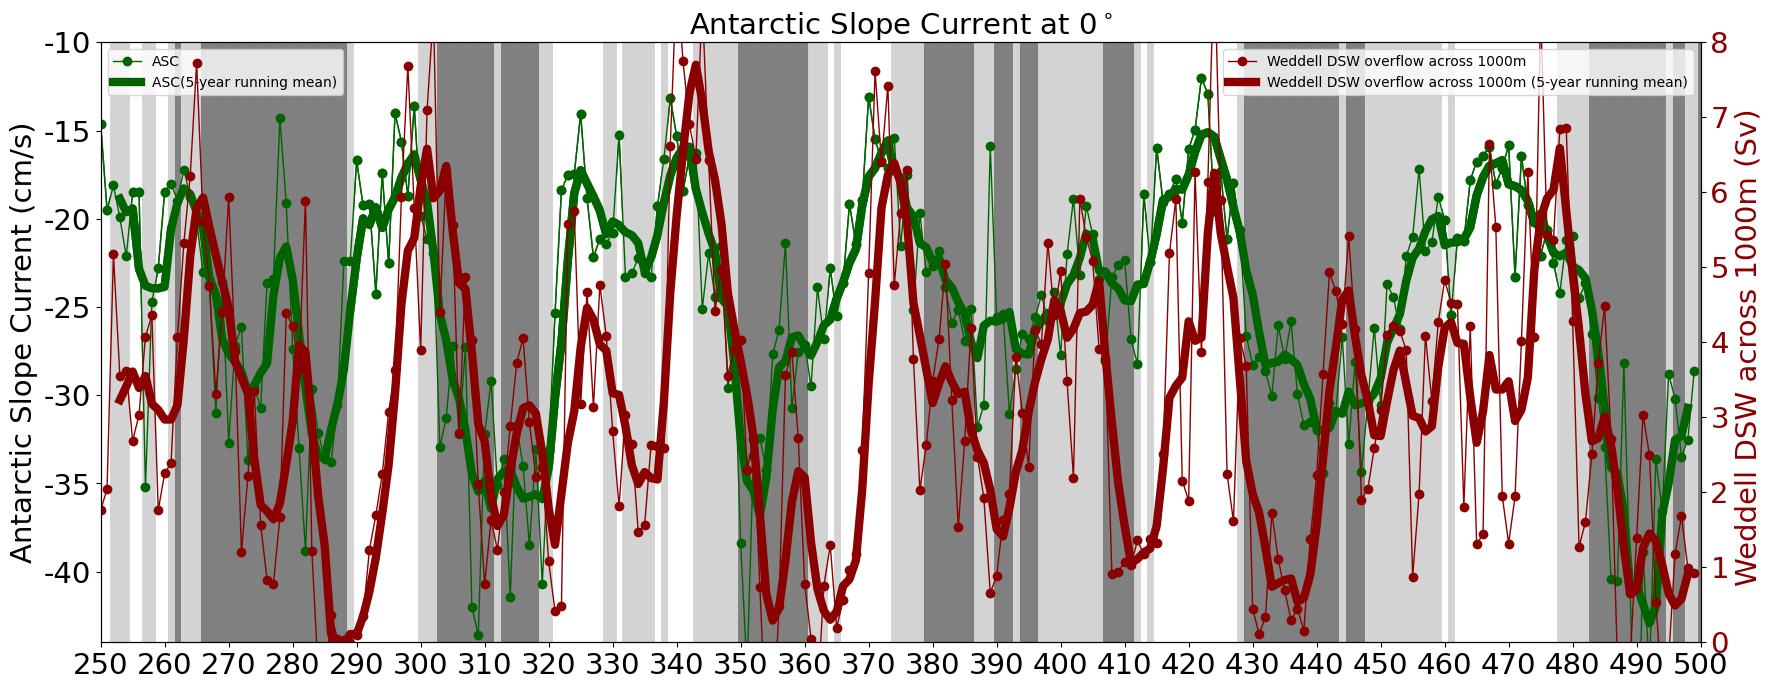

In [15]:
fig = plt.figure(figsize=(20,20), dpi=100)
my_font = {'size':'21'}
################################################################
################################################################
t = np.arange(3,249,1)
ax1 = fig.add_axes([0.1, 0.9, 0.8, 0.3],
                   xticklabels=[])
ax1.plot(all1,color='darkgreen',marker='o',linewidth=1,label='ASC')

ax1.plot(t, anom,color='darkgreen',linewidth=6,label='ASC(5-year running mean)')
plt.legend(loc='upper left')#,fontsize='xx-large')
#plt.legend()
plt.vlines(WSPbigger, -45, -10, linestyles="solid", colors="grey" ,linewidth=5)
plt.vlines(WSPno, -45, -10, linestyles="solid", colors="lightgrey" ,linewidth=5)
ax1.plot(all1,color='darkgreen',marker='o',linewidth=1,label='ASC')

ax1.plot(t, anom,color='darkgreen',linewidth=6,label='ASC(5-year running mean)')
plt.axis("tight")
plt.yticks(np.arange(-45,-5,5), ['-45','-40','-35','-30','-25','-20','-15','-10'],**my_font)
plt.ylabel('Antarctic Slope Current (cm/s)',**my_font)
plt.title('Antarctic Slope Current at 0$^\circ$',**my_font)
plt.xticks(np.arange(0,260,10), ['250','260','270','280','290','300','310','320','330','340','350','360','370','380','390','400','410','420','430','440','450','460','470','480','490','500'],**my_font)
ax1.set(ylim=(-44, -10),xlim=(0, 250))

ax2 = ax1.twinx()

ax2.plot(DSW1time,color='darkred',marker='o',linewidth=1,label='Weddell DSW overflow across 1000m')

ax2.plot(t,DSW1,color='darkred',linewidth=6,label='Weddell DSW overflow across 1000m (5-year running mean)')
plt.legend(loc='upper right')#,fontsize='xx-large')
plt.yticks(np.arange(0,10,1), ['0','1','2','3','4','5','6','7','8','9'],**my_font,color='darkred')
plt.ylabel('Weddell DSW across 1000m (Sv) ',**my_font,color='darkred')
#plt.legend()
ax2.set(ylim=(0, 8),xlim=(0, 250))


#plt.savefig("FigSS2g.png",bbox_inches='tight')

In [16]:
openocean = np.load('/media/ub/Elements/iHESPplot/SWMT/openoceandeep176runing.npy')
openoceantime = np.load('/media/ub/Elements/iHESPplot/SWMT/openoceandeeptime176runing.npy')

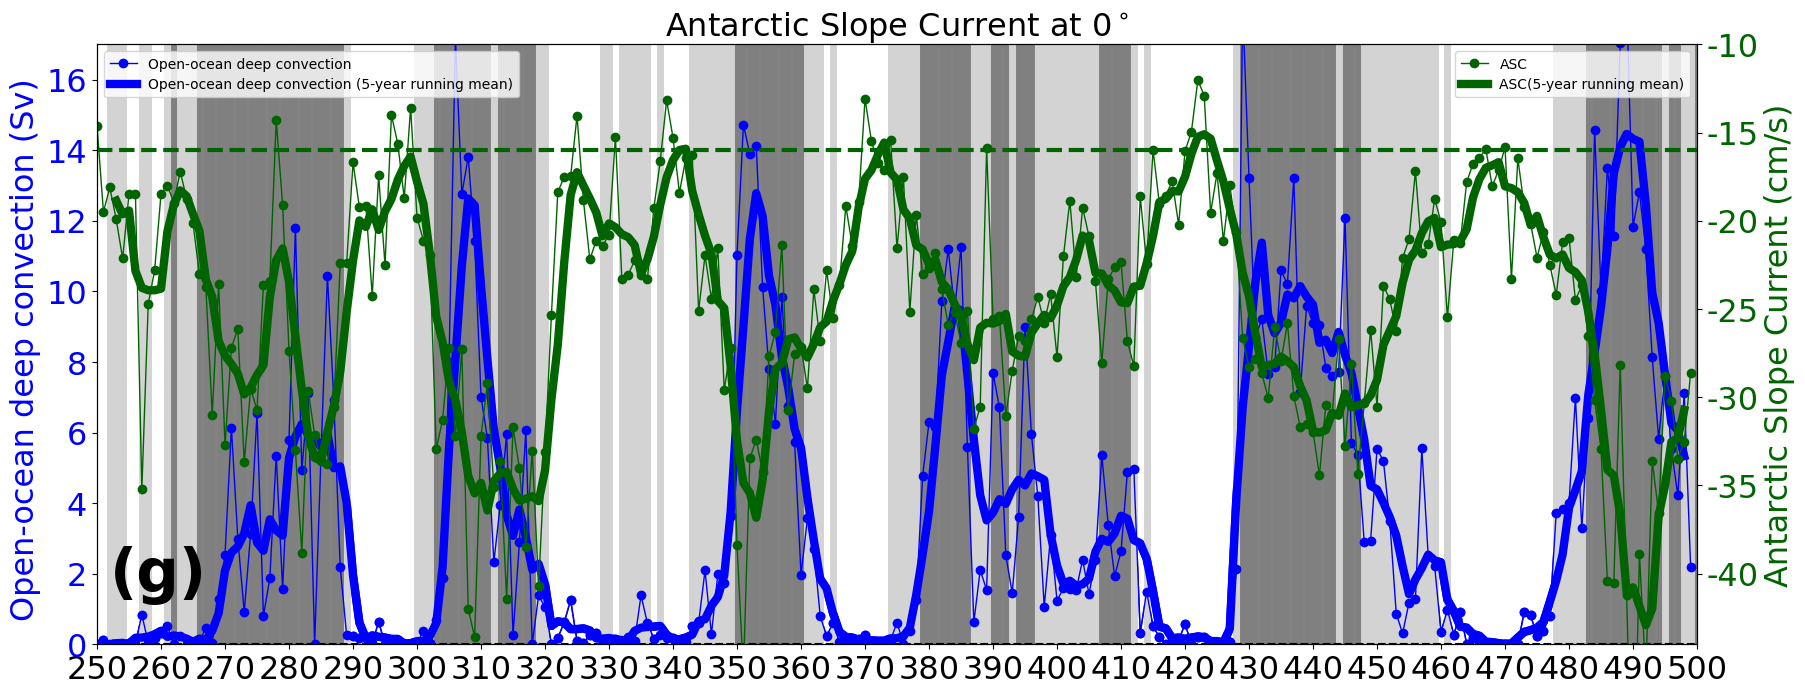

In [17]:
fig = plt.figure(figsize=(20,20), dpi=100)
my_font = {'size':'23'}
################################################################
################################################################
t = np.arange(3,249,1)
ax1 = fig.add_axes([0.1, 0.9, 0.8, 0.3],
                   xticklabels=[])


ax1.plot(openoceantime,color='blue',marker='o',linewidth=1,label='Open-ocean deep convection')

ax1.plot(t,openocean,color='blue',linewidth=6,label='Open-ocean deep convection (5-year running mean)')

plt.vlines(WSPbigger, 0, 17, linestyles="solid", colors="grey" ,linewidth=5)
plt.vlines(WSPno, 0, 17, linestyles="solid", colors="lightgrey" ,linewidth=5)
plt.legend(loc='upper left')#,fontsize='xx-large')
plt.hlines(0,0,250,linestyles="dashed", colors="black")
plt.axis("tight")
ax1.plot(openoceantime,color='blue',marker='o',linewidth=1,label='Open-ocean deep convection')

ax1.plot(t,openocean,color='blue',linewidth=6,label='Open-ocean deep convection (5-year running mean)')
plt.yticks(np.arange(0,20,2), ['0','2','4','6','8','10','12','14', '16', '18'],**my_font,color='blue')
plt.ylabel('Open-ocean deep convection (Sv) ',**my_font,color='blue')
#plt.title('Weddell DSW overflow across 1000m isodepth ($\sigma$$_1$>32.58)',**my_font)
plt.xticks(np.arange(0,260,10), ['250','260','270','280','290','300','310','320','330','340','350','360','370','380','390','400','410','420','430','440','450','460','470','480','490','500'],**my_font)
ax1.set(ylim=(0, 17),xlim=(0, 250))

#########################################


ax2 = ax1.twinx()
plt.hlines(-16, 0, 250, linestyles="dashed", colors="darkgreen" ,linewidth=3)
ax2.plot(all1,color='darkgreen',marker='o',linewidth=1,label='ASC')

ax2.plot(t, anom,color='darkgreen',linewidth=6,label='ASC(5-year running mean)')
plt.legend(loc='upper right')#,fontsize='xx-large')
#plt.legend()


plt.axis("tight")
plt.yticks(np.arange(-45,-5,5), ['-45','-40','-35','-30','-25','-20','-15','-10'],**my_font,color='darkgreen')
plt.ylabel('Antarctic Slope Current (cm/s)',**my_font,color='darkgreen')
plt.title('Antarctic Slope Current at 0$^\circ$',**my_font)
plt.xticks(np.arange(0,260,10), ['250','260','270','280','290','300','310','320','330','340','350','360','370','380','390','400','410','420','430','440','450','460','470','480','490','500'],**my_font)
ax2.set(ylim=(-44, -10),xlim=(0, 250))

#################
ax1.text(2, 1.5, '(g)',size=43, weight='bold',color='black')


plt.savefig("FigSS2g.png",bbox_inches='tight')

In [18]:
pwd

'/media/ub/Elements/iHESPplot/Paper3line'

In [19]:
np.save('speed.npy', all1)
np.save('speedrunning.npy', anom)